## Tiny NeRF (A PyTorch implementation)

So, this weekend, I was catching up on this _cool paper_ titled [*NeRF: Representing scenes as neural radiance fields for view synthesis*](https://arxiv.org/abs/2003.08934)!

The authors released a TensorFlow implementation [here](https://github.com/bmild/nerf). Deciding to delve deeper, I ported their code to PyTorch, cause why not!

> *DISCLAIMER*: This notebook (and repository) is work-in-progress. Although I have rigorously tested most modules in here (to faithfully replicate the original implementation), my implementation at places deviates from the authors'. Comments/criticism welcome!

> All functions that have a `#TESTED` under the docstring imply that they have been tested against their corresponding tensorflow impls.

In [1]:
# Import all the good stuff
from typing import Optional
import json
import os
from PIL import Image

import numpy as np
import torch
import matplotlib.pyplot as plt

## A few utility functions

#### Bridging PyTorch and TensorFlow functionality

There's plenty of differences in function signatures (and in functionality) b/w PyTorch and TensorFlow. Here's a few modules that help bridge the gap (for this particular impl).

In [2]:
def meshgrid_xy(tensor1: torch.Tensor, tensor2: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    """Mimick np.meshgrid(..., indexing="xy") in pytorch. torch.meshgrid only allows "ij" indexing.
    (If you're unsure what this means, safely skip trying to understand this, and run a tiny example!)

    Args:
      tensor1 (torch.Tensor): Tensor whose elements define the first dimension of the returned meshgrid.
      tensor2 (torch.Tensor): Tensor whose elements define the second dimension of the returned meshgrid.
    """
    # TESTED
    ii, jj = torch.meshgrid(tensor1, tensor2)
    return ii.transpose(-1, -2), jj.transpose(-1, -2)


def cumprod_exclusive(tensor: torch.Tensor) -> torch.Tensor:
  r"""Mimick functionality of tf.math.cumprod(..., exclusive=True), as it isn't available in PyTorch.

  Args:
    tensor (torch.Tensor): Tensor whose cumprod (cumulative product, see `torch.cumprod`) along dim=-1
      is to be computed.

  Returns:
    cumprod (torch.Tensor): cumprod of Tensor along dim=-1, mimiciking the functionality of
      tf.math.cumprod(..., exclusive=True) (see `tf.math.cumprod` for details).
  """
  # TESTED
  # Only works for the last dimension (dim=-1)
  dim = -1
  # Compute regular cumprod first (this is equivalent to `tf.math.cumprod(..., exclusive=False)`).
  cumprod = torch.cumprod(tensor, dim)
  # "Roll" the elements along dimension 'dim' by 1 element.
  cumprod = torch.roll(cumprod, 1, dim)
  # Replace the first element by "1" as this is what tf.cumprod(..., exclusive=True) does.
  cumprod[..., 0] = 1.

  return cumprod

#### Compute the "bundle" of rays through all pixels of an image.

In [3]:
def get_ray_bundle(height: int, width: int, focal_length: float, tform_cam2world: torch.Tensor):
  r"""Compute the bundle of rays passing through all pixels of an image (one ray per pixel).

  Args:
    height (int): Height of an image (number of pixels).
    width (int): Width of an image (number of pixels).
    focal_length (float or torch.Tensor): Focal length (number of pixels, i.e., calibrated intrinsics).
    tform_cam2world (torch.Tensor): A 6-DoF rigid-body transform (shape: :math:`(4, 4)`) that
      transforms a 3D point from the camera frame to the "world" frame for the current example.

  Returns:
    ray_origins (torch.Tensor): A tensor of shape :math:`(width, height, 3)` denoting the centers of
      each ray. `ray_origins[i][j]` denotes the origin of the ray passing through pixel at
      row index `j` and column index `i`.
      (TODO: double check if explanation of row and col indices convention is right).
    ray_directions (torch.Tensor): A tensor of shape :math:`(width, height, 3)` denoting the
      direction of each ray (a unit vector). `ray_directions[i][j]` denotes the direction of the ray
      passing through the pixel at row index `j` and column index `i`.
      (TODO: double check if explanation of row and col indices convention is right).
  """
  # TESTED
  ii, jj = meshgrid_xy(
      torch.arange(width).to(tform_cam2world),
      torch.arange(height).to(tform_cam2world)
  )
  directions = torch.stack([(ii - width * .5) / focal_length,
                            -(jj - height * .5) / focal_length,
                            -torch.ones_like(ii)
                           ], dim=-1)
  ray_directions = torch.sum(directions[..., None, :] * tform_cam2world[:3, :3], dim=-1)
  ray_origins = tform_cam2world[:3, -1].expand(ray_directions.shape)
  return ray_origins, ray_directions

#### Compute "query" 3D points given the "bundle" of rays.

We assume that a _near_ and a _far_ clipping distance are provided that delineate the volume of interest. Each ray is evaluated only within these bounds. We randomly sample points along each ray, while trying to ensure most parts of the ray's trajectory are spanned.

In [4]:
def compute_query_points_from_rays(
    ray_origins: torch.Tensor,
    ray_directions: torch.Tensor,
    near_thresh: float,
    far_thresh: float,
    num_samples: int,
    randomize: Optional[bool] = True
) -> (torch.Tensor, torch.Tensor):
  r"""Compute query 3D points given the "bundle" of rays. The near_thresh and far_thresh
  variables indicate the bounds within which 3D points are to be sampled.

  Args:
    ray_origins (torch.Tensor): Origin of each ray in the "bundle" as returned by the
      `get_ray_bundle()` method (shape: :math:`(width, height, 3)`).
    ray_directions (torch.Tensor): Direction of each ray in the "bundle" as returned by the
      `get_ray_bundle()` method (shape: :math:`(width, height, 3)`).
    near_thresh (float): The 'near' extent of the bounding volume (i.e., the nearest depth
      coordinate that is of interest/relevance).
    far_thresh (float): The 'far' extent of the bounding volume (i.e., the farthest depth
      coordinate that is of interest/relevance).
    num_samples (int): Number of samples to be drawn along each ray.
    randomize (optional, bool): Whether or not to randomize the sampling of query points.

  Returns:
    query_points (torch.Tensor): Query points along each ray
      (shape: :math:`(width, height, num_samples, 3)`).
    depth_values (torch.Tensor): Sampled depth values along each ray
      (shape: :math:`(num_samples)`).
  """
  depth_values = torch.linspace(near_thresh, far_thresh, num_samples).to(ray_origins)
  if randomize is True:
    noise_shape = list(ray_origins.shape[:-1]) + [num_samples]
    depth_values = depth_values + torch.rand(noise_shape).to(ray_origins) * (far_thresh - near_thresh) / num_samples
  query_points = ray_origins[..., None, :] + ray_directions[..., None, :] * depth_values[..., :, None]
  return query_points, depth_values


def compute_query_points_from_depth(
    ray_origins: torch.Tensor,
    ray_directions: torch.Tensor,
    depth_map: torch.Tensor,
    num_samples: int,
    depth_window: float = 0.15,
    randomize: Optional[bool] = True,
    min_depth: float = 1e-4,
    depth_is_euclidean: bool = True
) -> (torch.Tensor, torch.Tensor):
  r"""Compute query points by sampling each ray only around its depth-map value.

  Args:
    ray_origins (torch.Tensor): (width, height, 3)
    ray_directions (torch.Tensor): (width, height, 3)
    depth_map (torch.Tensor): depth image for the selected frame, shape (height, width) or (width, height).
    num_samples (int): number of samples around each depth value.
    depth_window (float): half-window (in depth units) around the depth center.
    randomize (bool): stratified perturbation inside bins.
    min_depth (float): minimum accepted depth value.
    depth_is_euclidean (bool): if True, depth_map is Euclidean camera-hit distance and is converted
      to the ray parameter used by NeRF sampling.

  Returns:
    query_points (torch.Tensor): (width, height, num_samples, 3)
    depth_values (torch.Tensor): (width, height, num_samples)
  """
  if depth_map.dim() == 3 and depth_map.shape[-1] == 1:
    depth_map = depth_map[..., 0]

  if depth_map.shape != ray_origins.shape[:2]:
    if depth_map.t().shape == ray_origins.shape[:2]:
      depth_map = depth_map.t()
    else:
      raise ValueError(
          f"Depth map shape {tuple(depth_map.shape)} is not compatible with rays {tuple(ray_origins.shape[:2])}"
      )

  depth_map = depth_map.to(ray_origins.dtype).to(ray_origins.device)
  valid_mask = torch.isfinite(depth_map) & (depth_map > min_depth)

  if torch.any(valid_mask):
    fallback_depth = torch.median(depth_map[valid_mask])
  else:
    fallback_depth = torch.tensor(1.0, dtype=ray_origins.dtype, device=ray_origins.device)

  depth_center = torch.where(valid_mask, depth_map, fallback_depth)

  offsets = torch.linspace(
      -depth_window,
      depth_window,
      num_samples,
      device=ray_origins.device,
      dtype=ray_origins.dtype
  )

  if depth_is_euclidean:
    ray_norm = torch.linalg.norm(ray_directions, dim=-1).clamp_min(1e-8)
    depth_center_t = depth_center / ray_norm
    depth_values = depth_center_t[..., None] + offsets[None, None, :] / ray_norm[..., None]
  else:
    depth_values = depth_center[..., None] + offsets

  if randomize is True and num_samples > 1:
    mids = 0.5 * (depth_values[..., 1:] + depth_values[..., :-1])
    upper = torch.cat([mids, depth_values[..., -1:]], dim=-1)
    lower = torch.cat([depth_values[..., :1], mids], dim=-1)
    depth_values = lower + (upper - lower) * torch.rand_like(depth_values)

  if depth_is_euclidean:
    min_t = (min_depth / ray_norm)[..., None]
    depth_values = torch.maximum(depth_values, min_t)
  else:
    depth_values = torch.clamp(depth_values, min=min_depth)

  query_points = ray_origins[..., None, :] + ray_directions[..., None, :] * depth_values[..., :, None]
  return query_points, depth_values

#### Volumetric rendering

> **NOTE**: This volumetric rendering module (like the authors' tiny_nerf [Colab notebook](https://colab.research.google.com/github/bmild/nerf/blob/master/tiny_nerf.ipynb) does not implement 5D input (which includes view directions, in addition to X, Y, Z coordinates). It also does not implement the hierarchical sampling procedure. For those implementations, refer to the other complete examples in the repo.

In [5]:
def render_volume_density(
    radiance_field: torch.Tensor,
    ray_origins: torch.Tensor,
    depth_values: torch.Tensor
) -> (torch.Tensor, torch.Tensor, torch.Tensor):
  r"""Differentiably renders a radiance field, given the origin of each ray in the
  "bundle", and the sampled depth values along them.

  Args:
    radiance_field (torch.Tensor): A "field" where, at each query location (X, Y, Z),
      we have an emitted (RGB) color and a volume density (denoted :math:`\sigma` in
      the paper) (shape: :math:`(width, height, num_samples, 4)`).
    ray_origins (torch.Tensor): Origin of each ray in the "bundle" as returned by the
      `get_ray_bundle()` method (shape: :math:`(width, height, 3)`).
    depth_values (torch.Tensor): Sampled depth values along each ray
      (shape: :math:`(num_samples)`).

  Returns:
    rgb_map (torch.Tensor): Rendered RGB image (shape: :math:`(width, height, 3)`).
    depth_map (torch.Tensor): Rendered depth image (shape: :math:`(width, height)`).
    acc_map (torch.Tensor): # TODO: Double-check (I think this is the accumulated
      transmittance map).
  """
  # TESTED
  sigma_a = torch.nn.functional.relu(radiance_field[..., 3])
  rgb = torch.sigmoid(radiance_field[..., :3])
  one_e_10 = torch.tensor([1e10], dtype=ray_origins.dtype, device=ray_origins.device)
  dists = torch.cat((depth_values[..., 1:] - depth_values[..., :-1],
                  one_e_10.expand(depth_values[..., :1].shape)), dim=-1)
  alpha = 1. - torch.exp(-sigma_a * dists)
  weights = alpha * cumprod_exclusive(1. - alpha + 1e-10)

  rgb_map = (weights[..., None] * rgb).sum(dim=-2)
  depth_map = (weights * depth_values).sum(dim=-1)
  acc_map = weights.sum(-1)

  return rgb_map, depth_map, acc_map

#### Positional encoding

Another interesting tweak used in NeRF is "positional encoding", which postulates the use of a mapping to higher dimensional space (using a basis set of high-frequency functions). This greatly enhances the model's capability to capture high-frequency variations.

In [6]:
def positional_encoding(
    tensor, num_encoding_functions=6, include_input=True, log_sampling=True
) -> torch.Tensor:
  r"""Apply positional encoding to the input.

  Args:
    tensor (torch.Tensor): Input tensor to be positionally encoded.
    num_encoding_functions (optional, int): Number of encoding functions used to
        compute a positional encoding (default: 6).
    include_input (optional, bool): Whether or not to include the input in the
        computed positional encoding (default: True).
    log_sampling (optional, bool): Sample logarithmically in frequency space, as
        opposed to linearly (default: True).

  Returns:
    (torch.Tensor): Positional encoding of the input tensor.
  """
  # TESTED
  # Trivially, the input tensor is added to the positional encoding.
  encoding = [tensor] if include_input else []
  # Now, encode the input using a set of high-frequency functions and append the
  # resulting values to the encoding.
  frequency_bands = None
  if log_sampling:
      frequency_bands = 2.0 ** torch.linspace(
            0.0,
            num_encoding_functions - 1,
            num_encoding_functions,
            dtype=tensor.dtype,
            device=tensor.device,
        )
  else:
      frequency_bands = torch.linspace(
          2.0 ** 0.0,
          2.0 ** (num_encoding_functions - 1),
          num_encoding_functions,
          dtype=tensor.dtype,
          device=tensor.device,
      )

  for freq in frequency_bands:
      for func in [torch.sin, torch.cos]:
          encoding.append(func(tensor * freq))

  # Special case, for no positional encoding
  if len(encoding) == 1:
      return encoding[0]
  else:
      return torch.cat(encoding, dim=-1)

## TinyNeRF: Network architecture

In [7]:
class VeryTinyNerfModel(torch.nn.Module):
  r"""Define a "very tiny" NeRF model comprising three fully connected layers.
  """
  def __init__(self, filter_size=128, num_encoding_functions=6):
    super(VeryTinyNerfModel, self).__init__()
    # Input layer (default: 39 -> 128)
    self.layer1 = torch.nn.Linear(3 + 3 * 2 * num_encoding_functions, filter_size)
    # Layer 2 (default: 128 -> 128)
    self.layer2 = torch.nn.Linear(filter_size, filter_size)
    # Layer 3 (default: 128 -> 4)
    self.layer3 = torch.nn.Linear(filter_size, 4)
    # Short hand for torch.nn.functional.relu
    self.relu = torch.nn.functional.relu

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.relu(self.layer2(x))
    x = self.layer3(x)
    return x

## NeRF: Network architecture

In [8]:
class VeryTinyNerfModel(torch.nn.Module):
  r"""Define a "very tiny" NeRF model comprising three fully connected layers.
  """
  def __init__(self, filter_size=128, num_encoding_functions=6):
    super(VeryTinyNerfModel, self).__init__()
    # Input layer (default: 39 -> 128)
    self.layer1 = torch.nn.Linear(3 + 3 * 2 * num_encoding_functions, filter_size)
    # Layer 2 (default: 128 -> 128)
    self.layer2 = torch.nn.Linear(filter_size, filter_size)
    # Layer 3 (default: 128 -> 4)
    self.layer3 = torch.nn.Linear(filter_size, 4)
    # Short hand for torch.nn.functional.relu
    self.relu = torch.nn.functional.relu

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.relu(self.layer2(x))
    x = self.layer3(x)
    return x

## Dataloading utils

In [9]:
def get_minibatches(inputs: torch.Tensor, chunksize: Optional[int] = 1024 * 8):
  r"""Takes a huge tensor (ray "bundle") and splits it into a list of minibatches.
  Each element of the list (except possibly the last) has dimension `0` of length
  `chunksize`.
  """
  return [inputs[i:i + chunksize] for i in range(0, inputs.shape[0], chunksize)]

## Get data

In [10]:
# Download sample data used in the official tiny_nerf example
import os
import urllib.request

if not os.path.exists("tiny_nerf_data.npz"):
    url = "http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz"
    urllib.request.urlretrieve(url, "tiny_nerf_data.npz")

# Note: You can also use a transforms.json file instead (see data loading cell)

## Determine device to run on (GPU vs CPU)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load up input images, poses, intrinsics, etc.

In [12]:
# Choose which data source to use
USE_TRANSFORMS_JSON = True
TRANSFORMS_JSON_PATH = "./output/sworshield_render/transforms_extended.json"


def resolve_existing_path(path_str: str, json_dir: str):
    candidates = []
    if path_str is None:
        return None

    normalized = path_str.replace('\\', os.sep).replace('/', os.sep)
    candidates.append(normalized)
    candidates.append(os.path.join(json_dir, normalized))
    candidates.append(os.path.join(os.getcwd(), normalized))
    candidates.append(os.path.join(os.getcwd(), normalized.lstrip('.\\/')))

    for candidate in candidates:
        candidate = os.path.normpath(candidate)
        if os.path.exists(candidate):
            return candidate
    return None


def load_exr_depth(exr_path: str) -> np.ndarray:
    import importlib

    try:
        OpenEXR = importlib.import_module('OpenEXR')
        Imath = importlib.import_module('Imath')
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Moduli mancanti per leggere EXR. Installa: pip install OpenEXR"
        ) from exc

    exr_file = OpenEXR.InputFile(exr_path)
    header = exr_file.header()
    dw = header['dataWindow']
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1
    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)

    # OptiX writes metric depth in channel Z.
    channels = list(header['channels'].keys())
    preferred_channels = ('Z', 'R', 'Y', 'X')
    channel_name = next((ch for ch in preferred_channels if ch in channels), channels[0])
    raw = exr_file.channel(channel_name, FLOAT)

    depth = np.frombuffer(raw, dtype=np.float32).reshape((height, width))
    return depth


if USE_TRANSFORMS_JSON:
    with open(TRANSFORMS_JSON_PATH, 'r') as f:
        transforms_data = json.load(f)

    json_dir = os.path.dirname(os.path.abspath(TRANSFORMS_JSON_PATH))

    # Camera intrinsics
    focal_length = transforms_data['fl_x']
    height = int(transforms_data['h'])
    width = int(transforms_data['w'])

    images_list = []
    poses_list = []
    depths_list = []

    for frame in transforms_data['frames']:
        img_path = resolve_existing_path(frame.get('file_path'), json_dir)
        depth_path = resolve_existing_path(frame.get('depth_path'), json_dir)

        if img_path is None:
            print(f"Warning: image not found for frame: {frame.get('file_path')}")
            continue
        if depth_path is None:
            print(f"Warning: depth not found for frame: {frame.get('depth_path')}")
            continue

        img = Image.open(img_path)
        img = np.array(img).astype(np.float32) / 255.0
        if img.ndim == 2:
            img = np.repeat(img[..., None], 3, axis=-1)
        if img.shape[-1] == 4:
            img = img[..., :3]

        depth = load_exr_depth(depth_path)
        if depth.shape != img.shape[:2]:
            print(f"Warning: depth/image shape mismatch for {os.path.basename(img_path)}: depth={depth.shape}, img={img.shape[:2]}")
            continue

        # keep metric depth values from EXR, only sanitize invalid entries
        depth = np.where(np.isfinite(depth), depth, 0.0).astype(np.float32)
        depth = np.where(depth > 0.0, depth, 0.0).astype(np.float32)

        images_list.append(img)
        poses_list.append(np.array(frame['transform_matrix'], dtype=np.float32))
        depths_list.append(depth)

    if len(images_list) < 2:
        raise RuntimeError("Servono almeno 2 frame validi (con immagine + depth) per train/test")

    images_np = np.stack(images_list, axis=0)
    poses_np = np.stack(poses_list, axis=0)
    depths_np = np.stack(depths_list, axis=0)

    # Hold one image out for validation
    test_idx = min(len(images_np) - 1, 5)
    testimg = torch.from_numpy(images_np[test_idx]).float().to(device)
    testpose = torch.from_numpy(poses_np[test_idx]).float().to(device)
    testdepth = torch.from_numpy(depths_np[test_idx]).float().to(device)

    train_indices = [i for i in range(len(images_np)) if i != test_idx]
    images = torch.from_numpy(images_np[train_indices]).float().to(device)
    tform_cam2world = torch.from_numpy(poses_np[train_indices]).float().to(device)
    depth_maps = torch.from_numpy(depths_np[train_indices]).float().to(device)
    focal_length = torch.tensor([focal_length], dtype=torch.float32).to(device)

    # kept for compatibility, not used by depth-guided sampling
    near_thresh = 2.0
    far_thresh = 6.0

    print(f"Loaded {len(images)} training images + 1 test image from {TRANSFORMS_JSON_PATH}")
    print(f"Image size: {height}x{width} | Focal: {focal_length.item():.4f}")
    print(f"Depth range (train): [{depth_maps[depth_maps > 0].min().item():.4f}, {depth_maps.max().item():.4f}]")

else:
    data = np.load("tiny_nerf_data.npz")

    images = data["images"]
    tform_cam2world = data["poses"]
    tform_cam2world = torch.from_numpy(tform_cam2world).to(device)
    focal_length = data["focal"]
    focal_length = torch.from_numpy(focal_length).to(device)

    height, width = images.shape[1:3]
    near_thresh = 2.
    far_thresh = 6.

    testimg, testpose = images[101], tform_cam2world[101]
    testimg = torch.from_numpy(testimg).to(device)

    images = torch.from_numpy(images[:100, ..., :3]).to(device)

    # Depth maps not available in tiny_nerf_data.npz mode
    depth_maps = None
    testdepth = None

    print(f"Loaded {len(images)} training images from tiny_nerf_data.npz")

Loaded 16 training images + 1 test image from ./output/sworshield_render/transforms_extended.json
Image size: 1080x1920 | Focal: 2666.6667
Depth range (train): [1.6379, 19999999961012895744.0000]


#### Display the image used for testing

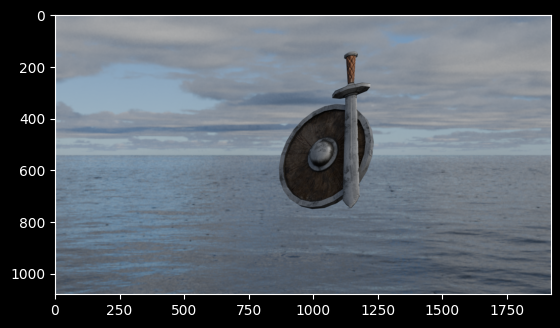

In [13]:
plt.imshow(testimg.detach().cpu().numpy())
plt.show()

## Train TinyNeRF!

(The cool part!)

In [14]:
# One iteration of TinyNeRF (forward pass).
def run_one_iter_of_tinynerf(height, width, focal_length, tform_cam2world,
                             near_thresh, far_thresh, depth_samples_per_ray,
                             encoding_function, get_minibatches_function,
                             target_depth=None, depth_window=0.15):

  # Get the "bundle" of rays through all image pixels.
  ray_origins, ray_directions = get_ray_bundle(height, width, focal_length,
                                               tform_cam2world)

  # Sample query points along each ray.
  if target_depth is not None:
    query_points, depth_values = compute_query_points_from_depth(
        ray_origins,
        ray_directions,
        target_depth,
        depth_samples_per_ray,
        depth_window=depth_window,
        randomize=True,
        depth_is_euclidean=True
    )
  else:
    query_points, depth_values = compute_query_points_from_rays(
        ray_origins, ray_directions, near_thresh, far_thresh, depth_samples_per_ray
    )

  # "Flatten" the query points.
  flattened_query_points = query_points.reshape((-1, 3))

  # Encode the query points (default: positional encoding).
  encoded_points = encoding_function(flattened_query_points)

  # Split encoded points into chunks to avoid out-of-memory.
  batches = get_minibatches_function(encoded_points, chunksize=chunksize)
  predictions = []
  for batch in batches:
    predictions.append(model(batch))
  radiance_field_flattened = torch.cat(predictions, dim=0)

  # "Unflatten" to obtain the radiance field.
  unflattened_shape = list(query_points.shape[:-1]) + [4]
  radiance_field = torch.reshape(radiance_field_flattened, unflattened_shape)

  # Perform differentiable volume rendering to re-synthesize the RGB image.
  rgb_predicted, _, _ = render_volume_density(radiance_field, ray_origins, depth_values)

  return rgb_predicted

C:\Users\adria\anaconda3\envs\nerfpytorch\lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4319.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loss: 0.26181864738464355


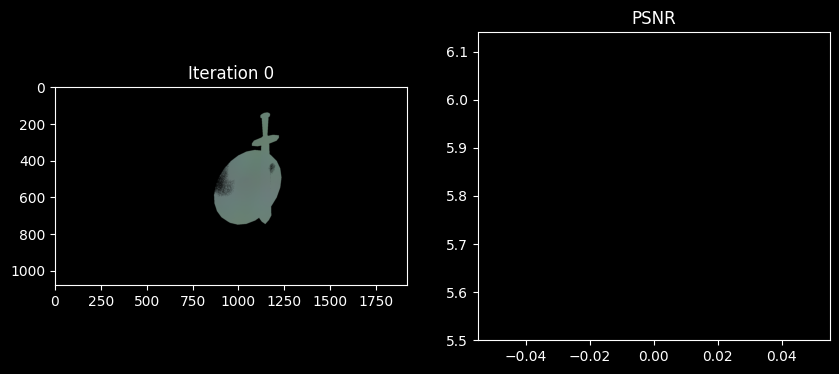

KeyboardInterrupt: 

In [15]:
"""
Parameters for TinyNeRF training
"""

import pickle

num_encoding_functions = 6
encode = lambda x: positional_encoding(x, num_encoding_functions=num_encoding_functions)
depth_samples_per_ray = 5
depth_window = 0.20  # sample only near the depth value for each pixel

chunksize = 16384

# Optimizer parameters
lr = 5e-3
num_iters = 10000

# Misc parameters
display_every = 100

# Texture baking params (runs once at the end)
ENABLE_TEXTURE_BAKE = True
POSITIONAL_MAP_EXR_PATH = "./output/ium/inverse_uv_mapping.exr"
OUTPUT_TEXTURE_PATH = "./output/ium/nerf_baked_texture.png"
OUTPUT_CONFIDENCE_PATH = "./output/ium/nerf_baked_confidence.png"

# Training cache params
ENABLE_MODEL_CACHE = True
MODEL_CACHE_PATH = "./output/model/tinynerf_model_cache.pkl"

"""
Model
"""
model = VeryTinyNerfModel(num_encoding_functions=num_encoding_functions)
model.to(device)

"""
Optimizer
"""
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

"""
Train-Eval-Repeat!
"""

seed = 9458
torch.manual_seed(seed)
np.random.seed(seed)

psnrs = []
iternums = []


def align_prediction_to_target(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
  if pred.shape == target.shape:
    return pred
  if pred.dim() == 3 and target.dim() == 3 and pred.permute(1, 0, 2).shape == target.shape:
    return pred.permute(1, 0, 2)
  raise ValueError(f"Prediction shape {tuple(pred.shape)} incompatible with target {tuple(target.shape)}")


def _resolve_path_for_texture(path_str: str) -> str:
  if path_str is None:
    return None
  candidates = [
      path_str,
      os.path.join(os.getcwd(), path_str),
      os.path.join(os.getcwd(), path_str.lstrip('./\\'))
  ]
  for candidate in candidates:
    candidate = os.path.normpath(candidate)
    if os.path.exists(candidate):
      return candidate
  return os.path.normpath(path_str)


def load_exr_position_map_rgba(exr_path: str) -> (np.ndarray, np.ndarray):
  import importlib

  try:
    OpenEXR = importlib.import_module('OpenEXR')
    Imath = importlib.import_module('Imath')
  except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Per leggere la positional map EXR installa: pip install OpenEXR") from exc

  exr_file = OpenEXR.InputFile(exr_path)
  header = exr_file.header()
  dw = header['dataWindow']
  width_exr = dw.max.x - dw.min.x + 1
  height_exr = dw.max.y - dw.min.y + 1
  FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)

  channels = list(header['channels'].keys())

  def _read_channel(*names):
    for name in names:
      if name in channels:
        raw = exr_file.channel(name, FLOAT)
        return np.frombuffer(raw, dtype=np.float32).reshape((height_exr, width_exr))
    return None

  x = _read_channel('R', 'X')
  y = _read_channel('G', 'Y')
  z = _read_channel('B', 'Z')
  a = _read_channel('A', 'alpha')

  if x is None or y is None or z is None:
    raise RuntimeError(f"Positional map EXR non valida: attesi canali RGB/XYZ, trovati {channels}")

  if a is None:
    a = np.ones((height_exr, width_exr), dtype=np.float32)

  position_map = np.stack([x, y, z], axis=-1).astype(np.float32)
  mask_map = a.astype(np.float32)
  return position_map, mask_map


def query_nerf_color_for_points_from_cameras_batch(
    points_world: torch.Tensor,
    cam2world_batch: torch.Tensor,
    sample_count: int,
    sample_window: float
  ) -> torch.Tensor:
  cam_pos = cam2world_batch[:, :3, 3]
  ray_dirs = points_world - cam_pos
  depth_euclid = torch.linalg.norm(ray_dirs, dim=-1).clamp_min(1e-8)

  ray_origins = cam_pos.unsqueeze(1)
  ray_directions = ray_dirs.unsqueeze(1)
  depth_map = depth_euclid.unsqueeze(1)

  query_points, depth_values = compute_query_points_from_depth(
      ray_origins,
      ray_directions,
      depth_map,
      num_samples=sample_count,
      depth_window=sample_window,
      randomize=False,
      depth_is_euclidean=True
  )

  flattened_query_points = query_points.reshape((-1, 3))
  encoded_points = encode(flattened_query_points)
  batches = get_minibatches(encoded_points, chunksize=chunksize)

  preds = []
  for batch in batches:
    preds.append(model(batch))
  radiance_field_flattened = torch.cat(preds, dim=0)

  n_pairs = points_world.shape[0]
  radiance_field = radiance_field_flattened.reshape(n_pairs, 1, sample_count, 4)
  rgb_pred, _, _ = render_volume_density(radiance_field, ray_origins, depth_values)
  return rgb_pred[:, 0, :]


def _save_model_cache(cache_path: str, iter_done: int):
  os.makedirs(os.path.dirname(os.path.normpath(cache_path)), exist_ok=True)
  payload = {
      'iter_done': int(iter_done),
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'seed': int(seed),
      'num_encoding_functions': int(num_encoding_functions)
  }
  with open(cache_path, 'wb') as f:
    pickle.dump(payload, f)
  print(f"[ModelCache] Salvato cache in: {cache_path}")


def _load_model_cache(cache_path: str) -> bool:
  if not os.path.exists(cache_path):
    return False

  with open(cache_path, 'rb') as f:
    payload = pickle.load(f)

  model.load_state_dict(payload['model_state_dict'])
  if 'optimizer_state_dict' in payload:
    optimizer.load_state_dict(payload['optimizer_state_dict'])
  print(f"[ModelCache] Cache caricata da: {cache_path} (iter_done={payload.get('iter_done', 'n/a')})")
  return True


def bake_texture_from_position_map(position_map_path: str,
                                   output_texture_path: str,
                                   output_confidence_path: str):
  if images is None or tform_cam2world is None:
    raise RuntimeError("Dataset non disponibile per texture baking")

  resolved_path = _resolve_path_for_texture(position_map_path)
  if resolved_path is None or (not os.path.exists(resolved_path)):
    raise FileNotFoundError(f"Positional map EXR non trovata: {position_map_path}")

  print(f"[TextureBake] Loading positional map: {resolved_path}")
  pos_map_np, mask_map_np = load_exr_position_map_rgba(resolved_path)

  h_tex, w_tex = pos_map_np.shape[:2]
  valid_mask_np = np.isfinite(pos_map_np).all(axis=-1) & (mask_map_np > 0.5)
  valid_coords_np = np.argwhere(valid_mask_np)  # (N, 2) -> (y, x)

  if valid_coords_np.shape[0] == 0:
    raise RuntimeError("Nessun texel valido trovato nella positional map")

  points = torch.from_numpy(pos_map_np[valid_mask_np]).to(device=device, dtype=torch.float32)

  cam_poses = tform_cam2world
  if cam_poses.dim() == 2:
    cam_poses = cam_poses.unsqueeze(0)

  n_tex = points.shape[0]
  focal_val = float(focal_length.item() if isinstance(focal_length, torch.Tensor) else focal_length)

  model_was_training = model.training
  model.eval()

  with torch.no_grad():
    # Project all valid texels into all cameras in batch
    world2cam = torch.linalg.inv(cam_poses)  # (C, 4, 4)
    points_h = torch.cat([points, torch.ones((n_tex, 1), device=device, dtype=points.dtype)], dim=-1)  # (N, 4)
    p_cam = torch.einsum('cij,nj->cni', world2cam, points_h)  # (C, N, 4)
    x_c = p_cam[..., 0]
    y_c = p_cam[..., 1]
    z_c = p_cam[..., 2]

    depth_cam = -z_c
    visible_z = z_c < -1e-6

    u = focal_val * (x_c / depth_cam.clamp_min(1e-8)) + (width * 0.5)
    v = -focal_val * (y_c / depth_cam.clamp_min(1e-8)) + (height * 0.5)
    visible_uv = (u >= 0) & (u <= (width - 1)) & (v >= 0) & (v <= (height - 1))

    # Use all visible cameras for each texel (no normal estimation, no top-k)
    valid = visible_z & visible_uv  # (C, N)
    pair_cam_ids, pair_texel_ids = torch.nonzero(valid, as_tuple=True)

    if pair_texel_ids.numel() == 0:
      raise RuntimeError("Nessuna coppia texel-camera valida trovata")

    pair_points = points[pair_texel_ids]
    pair_cams = cam_poses[pair_cam_ids]

    print(f"[TextureBake] Texel validi: {n_tex} | Coppie texel-camera: {pair_points.shape[0]}")

    pair_colors = query_nerf_color_for_points_from_cameras_batch(
        pair_points,
        pair_cams,
        sample_count=depth_samples_per_ray,
        sample_window=depth_window
    )  # (M, 3)

    # Simple arithmetic mean per texel (no weighted average)
    sum_count = torch.zeros((n_tex,), device=device, dtype=torch.float32)
    sum_rgb = torch.zeros((n_tex, 3), device=device, dtype=torch.float32)

    ones = torch.ones((pair_texel_ids.shape[0],), device=device, dtype=torch.float32)
    sum_count.index_add_(0, pair_texel_ids, ones)
    sum_rgb.index_add_(0, pair_texel_ids, pair_colors)

    mean_rgb = sum_rgb / sum_count.clamp_min(1.0)[:, None]

    # Confidence from unweighted color spread
    pair_dev = torch.linalg.norm(pair_colors - mean_rgb[pair_texel_ids], dim=-1)
    spread_sum = torch.zeros((n_tex,), device=device, dtype=torch.float32)
    spread_sum.index_add_(0, pair_texel_ids, pair_dev)
    spread = spread_sum / sum_count.clamp_min(1.0)
    conf_tex = torch.exp(-8.0 * spread).clamp(0.0, 1.0)
    conf_tex = torch.where(sum_count > 0, conf_tex, torch.zeros_like(conf_tex))

    # Scatter back to full texture grid
    texture = torch.zeros((h_tex, w_tex, 3), dtype=torch.float32, device=device)
    confidence = torch.zeros((h_tex, w_tex), dtype=torch.float32, device=device)

    valid_y = torch.from_numpy(valid_coords_np[:, 0]).to(device=device, dtype=torch.long)
    valid_x = torch.from_numpy(valid_coords_np[:, 1]).to(device=device, dtype=torch.long)

    texture[valid_y, valid_x] = mean_rgb.clamp(0.0, 1.0)
    confidence[valid_y, valid_x] = conf_tex

  if model_was_training:
    model.train()

  texture_np = texture.detach().cpu().numpy()
  confidence_np = confidence.detach().cpu().numpy()

  valid_texels = confidence_np > 0
  if np.any(valid_texels):
    fill_color = np.mean(texture_np[valid_texels], axis=0)
    texture_np[~valid_texels] = fill_color

  os.makedirs(os.path.dirname(os.path.normpath(output_texture_path)), exist_ok=True)
  os.makedirs(os.path.dirname(os.path.normpath(output_confidence_path)), exist_ok=True)

  tex_uint8 = (np.clip(texture_np, 0.0, 1.0) * 255.0).astype(np.uint8)
  conf_uint8 = (np.clip(confidence_np, 0.0, 1.0) * 255.0).astype(np.uint8)

  Image.fromarray(tex_uint8).save(output_texture_path)
  Image.fromarray(conf_uint8, mode='L').save(output_confidence_path)

  print(f"[TextureBake] Texture saved: {output_texture_path}")
  print(f"[TextureBake] Confidence saved: {output_confidence_path}")


skip_training = False

if ENABLE_MODEL_CACHE:
  cache_path_resolved = _resolve_path_for_texture(MODEL_CACHE_PATH)
  if cache_path_resolved is not None and os.path.exists(cache_path_resolved):
    skip_training = _load_model_cache(cache_path_resolved)

if not skip_training:
  for i in range(num_iters):
    target_img_idx = np.random.randint(images.shape[0])
    target_img = images[target_img_idx].to(device)
    target_tform_cam2world = tform_cam2world[target_img_idx].to(device)
    target_depth = depth_maps[target_img_idx].to(device) if depth_maps is not None else None

    rgb_predicted = run_one_iter_of_tinynerf(
        height,
        width,
        focal_length,
        target_tform_cam2world,
        near_thresh,
        far_thresh,
        depth_samples_per_ray,
        encode,
        get_minibatches,
        target_depth=target_depth,
        depth_window=depth_window
    )

    rgb_predicted = align_prediction_to_target(rgb_predicted, target_img)

    loss = torch.nn.functional.mse_loss(rgb_predicted, target_img)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if i % display_every == 0:
      rgb_eval = run_one_iter_of_tinynerf(
          height,
          width,
          focal_length,
          testpose,
          near_thresh,
          far_thresh,
          depth_samples_per_ray,
          encode,
          get_minibatches,
          target_depth=testdepth,
          depth_window=depth_window
      )

      rgb_eval = align_prediction_to_target(rgb_eval, testimg)
      eval_loss = torch.nn.functional.mse_loss(rgb_eval, testimg)
      print("Loss:", eval_loss.item())
      psnr = -10. * torch.log10(eval_loss)

      psnrs.append(psnr.item())
      iternums.append(i)

      plt.figure(figsize=(10, 4))
      plt.subplot(121)
      plt.imshow(rgb_eval.detach().cpu().numpy())
      plt.title(f"Iteration {i}")
      plt.subplot(122)
      plt.plot(iternums, psnrs)
      plt.title("PSNR")
      plt.show()

  if ENABLE_MODEL_CACHE:
    _save_model_cache(MODEL_CACHE_PATH, num_iters)
else:
  print("[ModelCache] Training saltato: modello caricato da cache")

if ENABLE_TEXTURE_BAKE:
  try:
    bake_texture_from_position_map(
        POSITIONAL_MAP_EXR_PATH,
        OUTPUT_TEXTURE_PATH,
        OUTPUT_CONFIDENCE_PATH
    )
  except Exception as exc:
    print(f"[TextureBake] Errore durante il baking finale: {exc}")

print('Done!')